# 01 · Merkmals- & SQI-Extraktion

**Bachelorarbeit: AF-Detektion in kontaktlosen Signalen · Nik Büttner · RWTH Aachen**

Dieses Notebook macht **genau eine Sache**: aus den Rohsignalen aller Patienten eine
aufgeräumte **Fenster-Tabelle** erzeugen und auf Platte speichern. Training und
Auswertung passieren im nächsten Notebook (`02_experts_gating.ipynb`) und laden nur
noch diese Tabelle — die teure Feature-Berechnung läuft also nur **einmal**.

### Was die Tabelle enthält (eine Zeile = ein 30-s-Fenster)

| Spaltengruppe | Inhalt | Wofür |
|---|---|---|
| `patient`, `AF`, `win_idx`, `t_start_s`, `n_valid_hrv` | Metadaten | Gruppen-Split & Nachvollziehbarkeit |
| `cecg_*` | Merkmale des cECG | **Experte 1** |
| `ppg1_*`, `ppg2_*` | Merkmale beider PPG | **Experte 2** |
| `bcg1_*`, `bcg2_*` | Merkmale beider BCG | **Experte 3** |
| `sqi_<signal>_*` | SQIs je Signal | **Gating-Netz** |

### Architektur, auf die das hinarbeitet
Drei Experten (je Modalität) liefern je eine **fensterweise AF-Wahrscheinlichkeit**.
Ein **Gating-Netz** liest die SQIs und gewichtet die drei Experten. Die gewichtete
Summe wird geschwellt → eine AF-Entscheidung pro Fenster.

> **Leakage-Hinweis (wichtig).** Das `AF`-Label ist ein *Patienten*-Label und wird auf
> jedes Fenster verteilt. Vorhergesagt wird **fensterweise**. Der Train/Test-Split muss
> aber **patientenweise** erfolgen (`groups = patient`, `LeaveOneGroupOut`) — sonst
> landen Fenster desselben Patienten in Training *und* Test. Die `patient`-Spalte
> liefert dafür den Gruppenschlüssel; gesplittet wird erst im Trainings-Notebook.


## 1 · Imports & Pfade

In [7]:
import os, sys
import numpy as np
import pandas as pd

# src/ auf den Pfad legen (dieses Notebook liegt in notebooks/)
NB_DIR  = os.path.abspath('')
SRC_DIR = os.path.abspath(os.path.join(NB_DIR, '..', 'src'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import extract as E   # neue, aufgeräumte Extraktion (nutzt features.py + sqi.py)

# Pfade — bei dir ggf. anpassen
DATA_ROOT   = '../data/patients/'      # Ordner mit PAT*-Unterordnern
AF_LIST     = '../data/AF_patients.txt'   # eine AF-Patienten-ID je Zeile
RESULTS_DIR = '../results/'                  # hier landet die Feature-Tabelle (Cache)
print('src:', SRC_DIR)

src: c:\Users\sshuser\Documents\BA\src


## 2 · Konfiguration

Alle Stellschrauben sitzen in einem `ExtractConfig`. Die Detektor-Voreinstellungen
entsprechen deinem bisher besten Stand (cECG: CWT-Morlet, PPG: heartpy, BCG: nogate).

`min_valid_hrv = 0` behält **alle** Fenster — für das Mixture-of-Experts sinnvoll: ein
totes cECG-Fenster kann über ein gutes PPG-Fenster trotzdem korrekt klassifiziert
werden, und das Gate lernt genau, ein schlechtes Signal abzuwerten. Fehlende Werte
übernimmt später der Imputer in den Modell-Pipelines.

In [8]:
cfg = E.ExtractConfig(
    data_root = DATA_ROOT,
    af_list   = AF_LIST,
    fs        = 128,
    window_s  = 30,
    hop_s     = 15,
    use_af_rr = True,
    min_valid_hrv = 0,   # 0 = alle Fenster behalten (empfohlen fürs Gate)
)
print('Fenster:', cfg.win, 'Samples ·  Hop:', cfg.hop, 'Samples')
print('Cache-Ziel:', cfg.cache_name(RESULTS_DIR))

Fenster: 3840 Samples ·  Hop: 1920 Samples
Cache-Ziel: ../results/features_sqi_cecg_cwt_d2721c.csv


## 3 · Extraktion (parallel, mit Cache)

Beim ersten Lauf werden alle Patienten parallel verarbeitet und das Ergebnis
gespeichert. Danach lädt die Zelle den Cache in Sekunden. `force=True` erzwingt
Neuberechnung (z. B. nach Detektor-Wechsel).

In [9]:
df = E.load_or_extract(cfg, RESULTS_DIR, n_jobs=8, force=False)
print('\nFeature-Tabelle:', df.shape)
df.head(3)

Kein Cache -> extrahiere ...
  PAT001 (AF): 119 Fenster
  PAT003 (Non-AF): 87 Fenster
  PAT004 (Non-AF): 119 Fenster
  PAT005 (Non-AF): 119 Fenster
  PAT006 (Non-AF): 119 Fenster
  PAT007 (Non-AF): 119 Fenster
  PAT008 (Non-AF): 119 Fenster
  PAT009 (Non-AF): 119 Fenster
  PAT010 (Non-AF): 119 Fenster
  PAT011 (Non-AF): 119 Fenster
  PAT012 (Non-AF): 119 Fenster
  PAT013 (Non-AF): 119 Fenster
  PAT014 (AF): 119 Fenster
  PAT015 (AF): 119 Fenster
  PAT016 (AF): 119 Fenster
  PAT017 (Non-AF): 119 Fenster
  PAT018 (Non-AF): 119 Fenster
  PAT019 (Non-AF): 119 Fenster
  PAT021 (Non-AF): 119 Fenster
  PAT022 (Non-AF): 119 Fenster
  PAT023 (Non-AF): 119 Fenster
  PAT024 (Non-AF): 119 Fenster
  PAT025 (AF): 119 Fenster
  PAT026 (AF): 119 Fenster
  PAT028 (AF): 119 Fenster
  PAT029 (AF): 115 Fenster
  PAT030 (AF): 119 Fenster
  PAT031 (AF): 119 Fenster
  PAT033 (AF): 119 Fenster
  PAT034 (AF): 119 Fenster
  PAT036 (AF): 119 Fenster
  PAT037 (AF): 119 Fenster
  PAT038 (AF): 119 Fenster
  PAT039 

,patient,AF,win_idx,t_start_s,n_valid_hrv,cecg_mean,cecg_std,cecg_skew,cecg_kurtosis,cecg_rms,...,bcg2_DFA_a1,bcg2_Lorenz_occ,bcg2_Lorenz_origin,bcg2_dRR_SD,sqi_bcg2_kSQI,sqi_bcg2_sSQI,sqi_bcg2_pSQI,sqi_bcg2_bSQI,sqi_bcg2_tSQI,sqi_bcg2_composite
0,PAT001,1,0,0.0,4,-0.000052,0.015162,2.310861,9.325084,0.015162,...,0.602218,25.0,0.040000,433.325775,0.767262,-0.014199,0.257044,0.700000,0.797026,0.675626
1,PAT001,1,1,15.0,4,-0.000113,0.016606,2.363359,9.536150,0.016606,...,0.779630,26.0,0.115385,250.977999,0.319295,0.007652,0.121082,0.650000,0.779759,0.626204
2,PAT001,1,2,30.0,5,0.000061,0.018039,1.626789,8.380286,0.018039,...,1.014305,27.0,0.111111,211.620652,0.538649,0.051207,0.207743,0.626506,0.756567,0.640606


## 4 · Datensatz-Übersicht

In [10]:
df, y, groups = E.split_Xygroups(df)

n_pat    = len(np.unique(groups))
n_pat_af = len(np.unique(groups[y == 1]))
print('=== Übersicht ===')
print(f'Patienten : {n_pat}  ({n_pat_af} AF / {n_pat - n_pat_af} Non-AF)')
print(f'Fenster   : {len(df)}  (AF {int(y.sum())} / Non-AF {int((1 - y).sum())})')

feat_cols = [c for c in df.columns if c not in E.META_COLS and not c.startswith('sqi_')]
sqi_cols  = [c for c in df.columns if c.startswith('sqi_')]
print(f'Merkmale  : {len(feat_cols)}   SQI-Spalten: {len(sqi_cols)}')
print(f'NaN-Anteil (Merkmale): {df[feat_cols].isna().mean().mean() * 100:.1f}%')

=== Übersicht ===
Patienten : 40  (19 AF / 21 Non-AF)
Fenster   : 4724  (AF 2257 / Non-AF 2467)
Merkmale  : 135   SQI-Spalten: 30
NaN-Anteil (Merkmale): 2.8%


## 5 · Spalten-Kontrolle: was bekommt welcher Block?

Hier sieht man schwarz auf weiß, dass die drei Experten ihre eigenen Signal-Merkmale
bekommen und das Gate die SQIs — sauber getrennt, kein Überlapp.

In [11]:
for m in ['cecg', 'ppg', 'bcg']:
    cols = E.expert_feature_cols(df, m)
    print(f'Experte {m:5s}: {len(cols):3d} Merkmale   z.B. {cols[:3]}')

print()
print('Gate (alle SQIs):', len(E.gate_sqi_cols(df, 'all')), 'Eingänge')
print('Gate (composite):', len(E.gate_sqi_cols(df, 'composite')), 'Eingänge ->',
      E.gate_sqi_cols(df, 'composite'))

Experte cecg :  27 Merkmale   z.B. ['cecg_mean', 'cecg_std', 'cecg_skew']
Experte ppg  :  54 Merkmale   z.B. ['ppg1_mean', 'ppg1_std', 'ppg1_skew']
Experte bcg  :  54 Merkmale   z.B. ['bcg1_mean', 'bcg1_std', 'bcg1_skew']

Gate (alle SQIs): 25 Eingänge
Gate (composite): 5 Eingänge -> ['sqi_cecg_composite', 'sqi_ppg1_composite', 'sqi_ppg2_composite', 'sqi_bcg1_composite', 'sqi_bcg2_composite']


## 6 · HRV-Verfügbarkeit je Signal (Diagnose)

Zeigt, wie oft jedes Signal eine HRV liefert. Bekanntes Bild: BCG ist rhythmus-arm,
PPG trägt das Signal. Das ist kein Fehler, sondern genau das, was das Gate später
ausnutzen soll.

Verteilung n_valid_hrv (Signale mit HRV je Fenster):
n_valid_hrv
2       2
3     349
4     472
5    3901


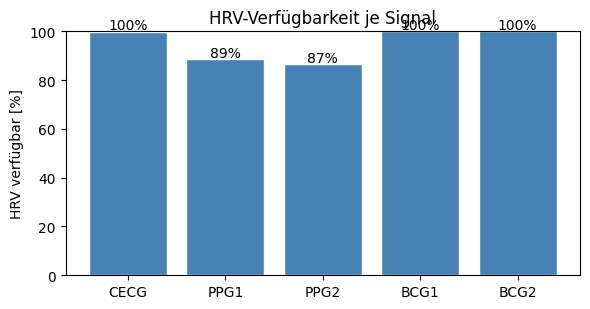

In [12]:
import matplotlib.pyplot as plt
rate = (df['n_valid_hrv']).value_counts().sort_index()
print('Verteilung n_valid_hrv (Signale mit HRV je Fenster):')
print(rate.to_string())

avail = {}
for s in E.SIGNALS:
    col = f'{s}_meanRR'
    if col in df.columns:
        avail[s.upper()] = df[col].notna().mean() * 100
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(list(avail), list(avail.values()), color='steelblue', edgecolor='white')
ax.set_ylabel('HRV verfügbar [%]'); ax.set_ylim(0, 100)
ax.set_title('HRV-Verfügbarkeit je Signal')
for i, v in enumerate(avail.values()):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center')
plt.tight_layout(); plt.show()

## Fertig — weiter in `02_experts_gating.ipynb`

Die Tabelle liegt jetzt als CSV im `data/`-Ordner. Das Trainings-Notebook lädt sie und:

1. trainiert **drei Experten** (`extract.expert_feature_cols(df, m)` liefert die Spalten),
2. erzeugt **leakage-freie Out-of-Fold-Wahrscheinlichkeiten** je Experte (innere CV),
3. trainiert das **Gating-Netz** auf den SQIs (`extract.gate_sqi_cols(df, ...)`),
4. fusioniert gewichtet und wertet **fensterweise** in **patientenweiser LOPO-CV** aus.

> Offene Frage an Blaß (klären, bevor das Gate gebaut wird): wird das Gate
> **end-to-end** auf die finale AF-Entscheidung trainiert (Mixture-of-Experts), oder
> **zweistufig** wie bei Bachelet (erst Zuverlässigkeit je Experte vorhersagen, dann
> daraus Gewichte ableiten)? Beides ist mit dieser Tabelle umsetzbar.
